In [1]:
import cv2
import os

def extract_frames(video_path, output_folder, interval_sec=10):
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_interval = int(fps * interval_sec)
    frame_count = 0
    saved_count = 0

    os.makedirs(output_folder, exist_ok=True)

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        if frame_count % frame_interval == 0:
            filename = os.path.join(output_folder, f"frame_{saved_count:03d}.png")
            cv2.imwrite(filename, frame)
            print(f"Saved: {filename}")
            saved_count += 1

        frame_count += 1

    cap.release()

# Usage
extract_frames('left.mp4', 'left_frames', interval_sec=10)
extract_frames('right.mp4', 'right_frames', interval_sec=10)


Saved: left_frames/frame_000.png
Saved: left_frames/frame_001.png
Saved: left_frames/frame_002.png
Saved: left_frames/frame_003.png
Saved: left_frames/frame_004.png
Saved: left_frames/frame_005.png
Saved: left_frames/frame_006.png
Saved: left_frames/frame_007.png
Saved: right_frames/frame_000.png
Saved: right_frames/frame_001.png
Saved: right_frames/frame_002.png
Saved: right_frames/frame_003.png
Saved: right_frames/frame_004.png
Saved: right_frames/frame_005.png
Saved: right_frames/frame_006.png
Saved: right_frames/frame_007.png


Processing Left Camera Images:


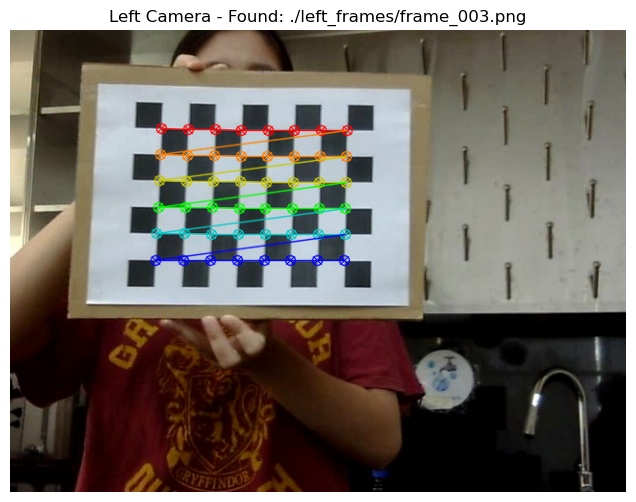

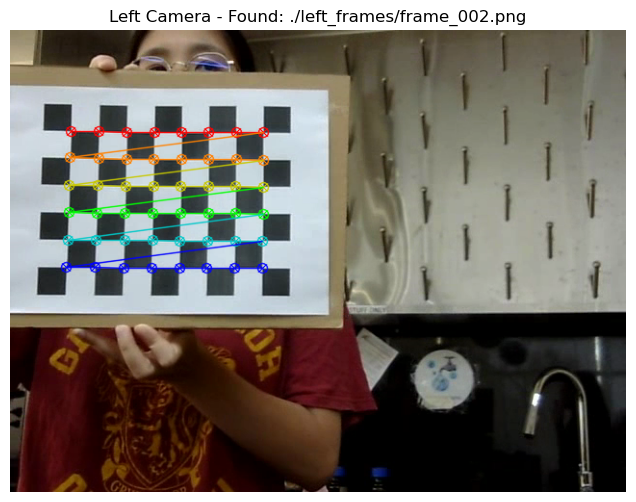

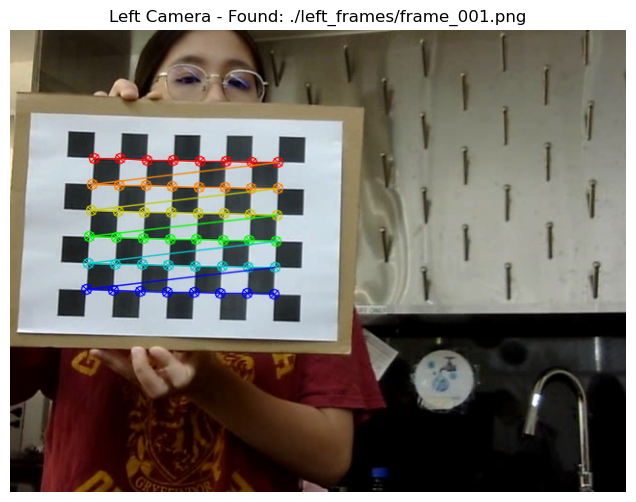

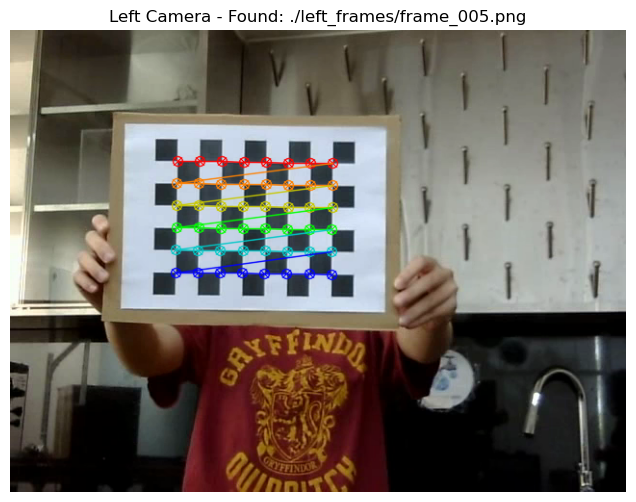

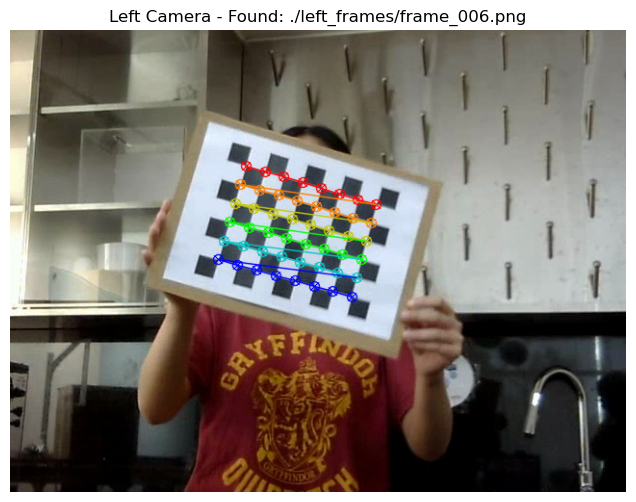

Processing Right Camera Images:


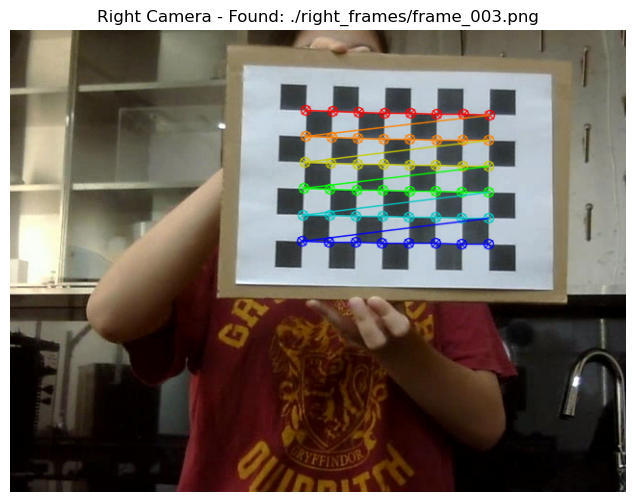

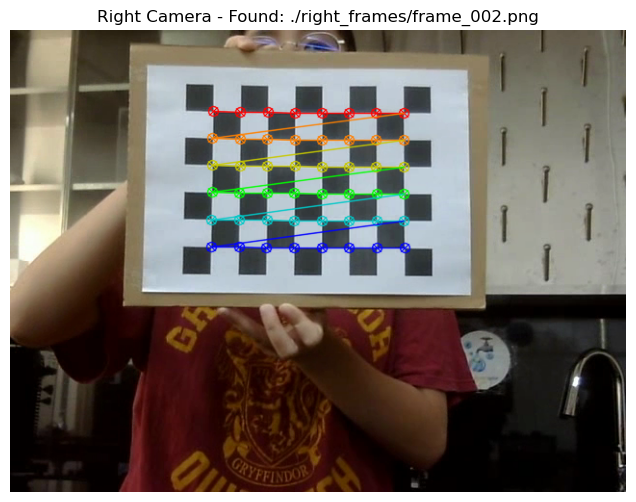

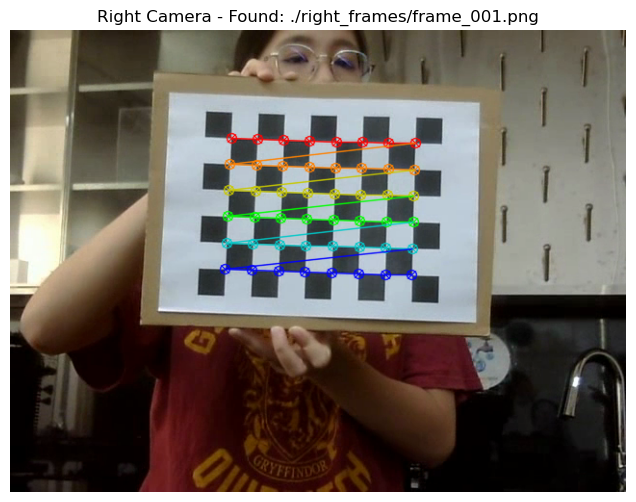

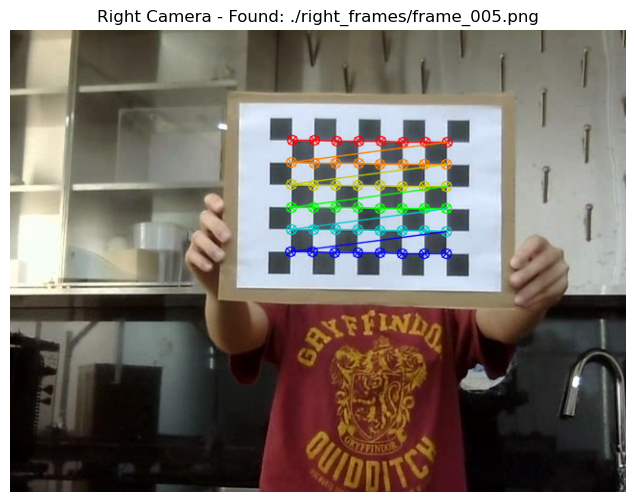

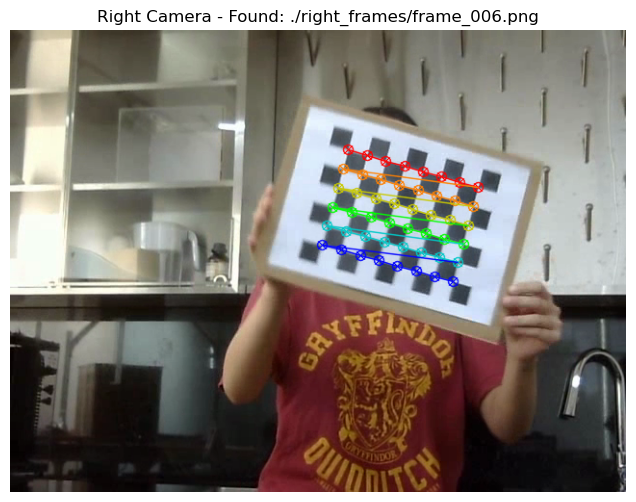

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob

# === CONFIG ===
CHESSBOARD_CORNER_NUM_X = 8
CHESSBOARD_CORNER_NUM_Y = 6
CHECKERBOARD_SIZE = (CHESSBOARD_CORNER_NUM_X, CHESSBOARD_CORNER_NUM_Y)
SQUARE_SIZE = 40  # mm (or any unit you are using)

LEFT_FOLDER = './left_frames/*.png'
RIGHT_FOLDER = './right_frames/*.png'

# termination criteria
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001)

# prepare object points, like (0,0,0), (40,0,0), ..., (280,200,0)
objp = np.zeros((CHESSBOARD_CORNER_NUM_X * CHESSBOARD_CORNER_NUM_Y, 3), np.float32)
objp[:, :2] = np.mgrid[0:CHESSBOARD_CORNER_NUM_X, 0:CHESSBOARD_CORNER_NUM_Y].T.reshape(-1, 2) * SQUARE_SIZE

# Process both folders
def process_folder(folder_path, title):
    images = glob.glob(folder_path)
    if not images:
        print(f"No images found in {folder_path}")
        return

    for fname in images:
        img = cv.imread(fname)
        if img is None:
            print(f"Failed to load image: {fname}")
            continue

        gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        ret, corners = cv.findChessboardCorners(gray, CHECKERBOARD_SIZE, None)

        fig, ax = plt.subplots(figsize=(8, 6))
        if ret:
            corners2 = cv.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
            cv.drawChessboardCorners(img, CHECKERBOARD_SIZE, corners2, ret)
            ax.set_title(f"{title} - Found: {fname}")
        else:
            ax.set_title(f"{title} - Not Found: {fname}")
            print(f'Failed to find a chessboard in {fname}')

        ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        ax.axis('off')
        plt.show()

# Run for both left and right folders
print("Processing Left Camera Images:")
process_folder(LEFT_FOLDER, title="Left Camera")

print("Processing Right Camera Images:")
process_folder(RIGHT_FOLDER, title="Right Camera")


In [36]:
import cv2
import numpy as np
import glob
import os

# === CONFIGURATION ===
CHECKERBOARD = (8, 6)  # Size of the checkerboard used for calibration (corners inside)
LEFT_IMAGES_DIR = './left_frames'  # Folder for left camera images
RIGHT_IMAGES_DIR = './right_frames'  # Folder for right camera images
OUTPUT_DIR = 'output'
os.makedirs(OUTPUT_DIR, exist_ok=True)  # Ensure output directory exists

# === STEP 1: Stereo Calibration ===
def stereo_calibrate(checkerboard_size, left_dir, right_dir):
    # Termination criteria for corner refinement algorithm
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)

    # Prepare object points (3D points in real world space)
    objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1, 2)

    # Lists to store object points and image points
    objpoints = []  # 3D points in real world space
    imgpoints_left = []  # 2D points in left image plane
    imgpoints_right = []  # 2D points in right image plane

    # Load calibration images
    left_images = sorted(glob.glob(os.path.join(left_dir, '*.png')))
    right_images = sorted(glob.glob(os.path.join(right_dir, '*.png')))

    if not left_images or not right_images:
        raise ValueError("No calibration images found in the given directories.")

    for left_path, right_path in zip(left_images, right_images):
        img_left = cv2.imread(left_path)
        img_right = cv2.imread(right_path)

        if img_left is None or img_right is None:
            print(f"Warning: Couldn't read image pair {left_path} and {right_path}. Skipping.")
            continue

        gray_left = cv2.cvtColor(img_left, cv2.COLOR_BGR2GRAY)
        gray_right = cv2.cvtColor(img_right, cv2.COLOR_BGR2GRAY)

        # Find the chessboard corners
        ret_left, corners_left = cv2.findChessboardCorners(gray_left, checkerboard_size, None)
        ret_right, corners_right = cv2.findChessboardCorners(gray_right, checkerboard_size, None)

        if ret_left and ret_right:
            objpoints.append(objp)

            # Refine corner locations to sub-pixel accuracy
            corners_left = cv2.cornerSubPix(gray_left, corners_left, (11, 11), (-1, -1), criteria)
            corners_right = cv2.cornerSubPix(gray_right, corners_right, (11, 11), (-1, -1), criteria)

            imgpoints_left.append(corners_left)
            imgpoints_right.append(corners_right)
        else:
            print(f"Chessboard not found in {left_path} and {right_path}.")

    if not objpoints:
        raise ValueError("No valid chessboard corners were found.")

    image_size = gray_left.shape[::-1]

    # Individual camera calibration
    _, mtx_left, dist_left, _, _ = cv2.calibrateCamera(objpoints, imgpoints_left, image_size, None, None)
    _, mtx_right, dist_right, _, _ = cv2.calibrateCamera(objpoints, imgpoints_right, image_size, None, None)

    # Stereo calibration (get rotation R, translation T, essential and fundamental matrices)
    _, _, _, _, _, R, T, E, F = cv2.stereoCalibrate(
        objpoints, imgpoints_left, imgpoints_right,
        mtx_left, dist_left,
        mtx_right, dist_right,
        image_size,
        criteria=criteria,
        flags=cv2.CALIB_FIX_INTRINSIC  # Assume intrinsics are fixed (more accurate)
    )

    print("Stereo calibration successful.")
    return mtx_left, dist_left, mtx_right, dist_right, R, T

# === STEP 2: Rectify Images ===
def rectify_pair(img_left, img_right, mtx_left, dist_left, mtx_right, dist_right, R, T):
    image_size = (img_left.shape[1], img_left.shape[0])

    # Compute rectification transforms
    R1, R2, P1, P2, Q, _, _ = cv2.stereoRectify(
        mtx_left, dist_left,
        mtx_right, dist_right,
        image_size, R, T, alpha=0
    )

    # Compute rectification maps
    map1x, map1y = cv2.initUndistortRectifyMap(mtx_left, dist_left, R1, P1, image_size, cv2.CV_32FC1)
    map2x, map2y = cv2.initUndistortRectifyMap(mtx_right, dist_right, R2, P2, image_size, cv2.CV_32FC1)

    # Apply rectification
    rectified_left = cv2.remap(img_left, map1x, map1y, cv2.INTER_LINEAR)
    rectified_right = cv2.remap(img_right, map2x, map2y, cv2.INTER_LINEAR)

    return rectified_left, rectified_right, Q

# === STEP 3: Compute Disparity Map ===
def compute_disparity_map(rectified_left, rectified_right):
    gray_left = cv2.cvtColor(rectified_left, cv2.COLOR_BGR2GRAY)
    gray_right = cv2.cvtColor(rectified_right, cv2.COLOR_BGR2GRAY)

    # Stereo SGBM matcher - Semi-Global Block Matching
    stereo = cv2.StereoSGBM_create(
        minDisparity=0,
        numDisparities=16 * 5,  # Should be divisible by 16
        blockSize=5,  # Small block size for better detail
        P1=8 * 3 * 5 ** 2,
        P2=32 * 3 * 5 ** 2,
        mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY  # Faster and good quality
    )

    disparity = stereo.compute(gray_left, gray_right).astype(np.float32) / 16.0

    # Normalize for visualization
    disp_vis = cv2.normalize(disparity, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX)
    disp_vis = np.uint8(disp_vis)
    cv2.imwrite(os.path.join(OUTPUT_DIR, 'disparity_map.png'), disp_vis)
    print("Disparity map saved.")

    return disparity

# === STEP 4: Generate Point Cloud ===
def generate_point_cloud(disparity, rectified_left, Q, output_file='output/point_cloud.ply'):
    # Reproject disparity to 3D space
    points_3D = cv2.reprojectImageTo3D(disparity, Q)
    colors = cv2.cvtColor(rectified_left, cv2.COLOR_BGR2RGB)
    mask = disparity > disparity.min()

    output_points = points_3D[mask]
    output_colors = colors[mask]

    # Write to PLY file
    with open(output_file, 'w') as f:
        f.write('ply\nformat ascii 1.0\nelement vertex {}\n'.format(len(output_points)))
        f.write('property float x\nproperty float y\nproperty float z\n')
        f.write('property uchar red\nproperty uchar green\nproperty uchar blue\nend_header\n')
        for p, c in zip(output_points, output_colors):
            f.write(f"{p[0]} {p[1]} {p[2]} {c[0]} {c[1]} {c[2]}\n")

    print(f"Point cloud saved to {output_file}")

# === MAIN PIPELINE ===
if __name__ == '__main__':
    # Step 1: Stereo Calibration
    mtx_left, dist_left, mtx_right, dist_right, R, T = stereo_calibrate(CHECKERBOARD, LEFT_IMAGES_DIR, RIGHT_IMAGES_DIR)

    # Step 2: Rectify a sample image pair
    sample_left = cv2.imread(os.path.join(LEFT_IMAGES_DIR, 'frame_003.png'))  # Change to your actual file
    sample_right = cv2.imread(os.path.join(RIGHT_IMAGES_DIR, 'frame_003.png'))  # Change to your actual file
    rect_left, rect_right, Q = rectify_pair(sample_left, sample_right, mtx_left, dist_left, mtx_right, dist_right, R, T)

    # Step 3: Compute disparity
    disparity = compute_disparity_map(rect_left, rect_right)

    # Step 4: Generate point cloud
    generate_point_cloud(disparity, rect_left, Q)

Stereo calibration successful.
Disparity map saved.
Point cloud saved to output/point_cloud.ply
